# Personalization:


In [1]:
from cProfile import label

import pandas as pd
import numpy as np
import cv2
from pathlib import Path
import os
import time

In [11]:
root_folder = Path("./personalization/")
text_files = []
video_files = []

for f, folder in enumerate(sorted(root_folder.iterdir())):

    if folder.is_dir():

        # print(f"\nfolder_name: {folder.name}")
        images_folder = Path(f"{root_folder}/{folder.name}/images")
        images_folder.mkdir(
                parents=True,
                exist_ok=True
            )
        # os.makedirs("images", exist_ok=True)

        for file in folder.iterdir():

            if file.suffix == ".txt" and file.name == f"{folder.name}_position.txt":
                # print("TXT gefunden:", file)
                txt_file = Path(f"{root_folder}/{folder.name}/{folder.name}_position.txt")
                # print(f"Text_File: {txt_file.as_posix()}\n")
                text_files.append(txt_file.as_posix())


                

            elif file.suffix == ".mp4":
                # print("MP4 gefunden:", file)
                video_file = Path(f"{root_folder}/{folder.name}/{folder.name}_video.mp4")
                # print(f"Video_File: {video_file.as_posix()}\n")
                video_files.append(video_file.as_posix())

print(f"\nText_Files: {text_files}")
print(f"\nlen(Text_Files) : {len(text_files)}")

print(f"\nVideo_Files: {video_files}")
print(f"\nlen(Video_Files) : {len(video_files)}")


Text_Files: ['personalization/01/01_position.txt', 'personalization/02/02_position.txt', 'personalization/03/03_position.txt', 'personalization/04/04_position.txt', 'personalization/05/05_position.txt', 'personalization/06/06_position.txt', 'personalization/07/07_position.txt', 'personalization/08/08_position.txt', 'personalization/09/09_position.txt', 'personalization/10/10_position.txt', 'personalization/11/11_position.txt', 'personalization/12/12_position.txt', 'personalization/13/13_position.txt', 'personalization/14/14_position.txt', 'personalization/15/15_position.txt', 'personalization/16/16_position.txt', 'personalization/17/17_position.txt', 'personalization/18/18_position.txt']

len(Text_Files) : 18

Video_Files: ['personalization/01/01_video.mp4', 'personalization/02/02_video.mp4', 'personalization/03/03_video.mp4', 'personalization/04/04_video.mp4', 'personalization/05/05_video.mp4', 'personalization/06/06_video.mp4', 'personalization/07/07_video.mp4', 'personalization/08/

In [15]:

# step 3:

print("Anzahl Textdateien :", len(text_files))
print("Anzahl Videodateien:", len(video_files))

if len(text_files) != len(video_files):
    print("\nText files:")
    for i1, f1 in enumerate(text_files):
        print(i1, f1)
        # continue

    print("\nVideo files:")
    for i2, f2 in enumerate(video_files):
        print(i2, f2)
        # continue


# elif len(text_files) == len(video_files):
#     f = len(video_files)

# for session_id in range(1, f+1):

#     subject_name = str(session_id)

for i in range(len(text_files)):

    labels = pd.read_csv(text_files[i], sep=",") 
    # print(labels.head())
    # print(labels.columns)

    labels.columns = labels.columns.str.strip()

    # subject_name = f"{text_files[i].split('/')[1]}"
    subject_name = Path(text_files[i]).parent.name
    
    print(f"\nsubject_name: {subject_name}\n")

    images_folder = Path(f"./personalization") / subject_name / "images"

    images_folder.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_files[i])

    rows = []
    norm_rows = []
    frame_id = 0
    saved_id = 0

    FPS = 30
    Steps = 5

    effective_fps = FPS / Steps

    # print(f"Original FPS: {FPS}")
    # print(f"Steps: {Steps}")
    # print(f"Effektive FPS: {effective_fps}")

    # Min und Max berechnen
    x_min = labels["x"].min()
    x_max = labels["x"].max()

    y_min = labels["y"].min()
    y_max = labels["y"].max()

    # print(f"x_min = {x_min}, x_max = {x_max}")
    # print(f"y_min = {y_min}, y_max = {y_max}")

    if (np.abs(1430 - x_max) < 100) and (np.abs(880 - y_max) < 100):
        
        x_Max, y_Max = 1430, 880
        # print(1430 - x_max)
        

    elif (np.abs(1870 - x_max) < 100) and (np.abs(1000 - y_max) < 100):

        x_Max, y_Max = 1870, 1000
        # print(1870 - x_max)
        

    
    # if subject_name == '01' or subject_name == '02' or subject_name == '03' or subject_name == '04': 
    #     x_max, y_max = 1430, 880
        # x_max, y_max = 1870, 1000
        
        # print(f"System: {sys1}")
        # print(f"\nX_max = {x_max}, Y_max = {y_max}")

    # if (
    #     subject_name == '05' or subject_name == '06' or subject_name == '07' or subject_name == '08' or subject_name == '09' 
    #     or subject_name == '07' or subject_name == '08' or subject_name == '09'):

    # elif subject_name == '11':
    #     continue
    
    # else:
    #     x_max, y_max = 1870, 1000
        
        # print(f"System: {sys2}")
        # print(f"\nX_max = {x_max}, Y_max = {y_max}")
        
    print(f" X_max = {x_Max},\n Y_max = {y_Max}")
    # X_max = 1430, Y_max = 880

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % Steps == 0:

            filename = f"{saved_id:04d}.jpg"

            image_path = images_folder / filename

            cv2.imwrite(str(image_path), frame)

            label = labels.loc[labels["frame"] == frame_id].iloc[0]

            rows.append({
                "frame": filename,
                "x": max(0, float(f"{label['x']:.6f}")),
                "y": max(0, float(f"{label['y']:.6f}"))
            })

            norm_rows.append({
                "frame": filename,
                "x": min(max(0, float(f"{label['x'] / x_Max:.6f}")), 1),
                "y": min(max(0, float(f"{label['y'] / y_Max:.6f}")), 1)
            })


            # rows.append({
            #     "frame": filename,
            #     "x": max(0, float(f"{(labels.loc[frame_id, "x"]):.6f}")),
            #     "y": max(0, float(f"{(labels.loc[frame_id, "y"]):.6f}"))
            # })

            # norm_rows.append({
            #     "frame": filename,
            #     "x": min(max(0, float(f"{(labels.loc[frame_id, "x"] / x_Max):.6f}")), 1),
            #     "y": min(max(0, float(f"{(labels.loc[frame_id, "y"] / y_Max):.6f}")), 1)
            # })

            saved_id += 1


        frame_id += 1

    cap.release()

    pd.DataFrame(rows).to_csv(
        f"./personalization/{subject_name}/labels.csv", index=False
    )

    pd.DataFrame(norm_rows).to_csv(
        f"./personalization/{subject_name}/norm_labels.csv", index=False
        )

Anzahl Textdateien : 18
Anzahl Videodateien: 18

subject_name: 01

 X_max = 1430,
 Y_max = 880

subject_name: 02

 X_max = 1430,
 Y_max = 880

subject_name: 03

 X_max = 1430,
 Y_max = 880

subject_name: 04

 X_max = 1430,
 Y_max = 880

subject_name: 05

 X_max = 1870,
 Y_max = 1000

subject_name: 06

 X_max = 1870,
 Y_max = 1000

subject_name: 07

 X_max = 1870,
 Y_max = 1000

subject_name: 08

 X_max = 1870,
 Y_max = 1000

subject_name: 09

 X_max = 1870,
 Y_max = 1000

subject_name: 10

 X_max = 1870,
 Y_max = 1000

subject_name: 11

 X_max = 1870,
 Y_max = 1000

subject_name: 12

 X_max = 1870,
 Y_max = 1000

subject_name: 13

 X_max = 1870,
 Y_max = 1000

subject_name: 14

 X_max = 1870,
 Y_max = 1000

subject_name: 15

 X_max = 1870,
 Y_max = 1000

subject_name: 16

 X_max = 1870,
 Y_max = 1000

subject_name: 17

 X_max = 1870,
 Y_max = 1000

subject_name: 18

 X_max = 1870,
 Y_max = 1000


# Nur für Session 10, 11, 12, bis 18 wenn man andere Struktur braucht:

In [8]:
# ==========================================================
# Video + Labels verarbeiten
# ==========================================================

print("Anzahl Textdateien :", len(text_files))
print("Anzahl Videodateien:", len(video_files))

if len(text_files) != len(video_files):
    print("\nText files:")
    for i1, f1 in enumerate(text_files):
        print(i1, f1)
        # continue

    print("\nVideo files:")
    for i2, f2 in enumerate(video_files):
        print(i2, f2)
        # continue
        

for i in range(len(text_files) + 1):

    if str(i+1) in ['10', '11', '12', '13', '14', '15', '16', '17' , '18']:

        # ------------------------------------------------------
        # Subject bestimmen
        # ------------------------------------------------------

        subject_name = Path(text_files[i]).parent.name

        # print(f"\n========================================")
        print(f"\n\nSubject: {subject_name}\n")
        # print(f"========================================")


        # ------------------------------------------------------
        # Neues / altes Format erkennen
        # ------------------------------------------------------

        new_format = True       #  Format: segment_id + frame + x + y + phase


        # ------------------------------------------------------
        # Labels laden
        # ------------------------------------------------------
        labels = pd.read_csv(
            text_files[i],
            sep=","
        )

        # start P1:   ###########################
        print(
            f"Subject {subject_name}: "
            f"Label frames: {labels.index.min()} - {labels.index.max()}"
        )

        # end P1:     ###########################

        labels.columns = labels.columns.str.strip()


        # ------------------------------------------------------
        # Prüfen, ob erwartete Spalten vorhanden sind
        # ------------------------------------------------------

        required_columns = [
            "segment_id",
            "frame",
            "x",
            "y",
            "phase"
        ]


        missing_columns = [
            col for col in required_columns
            if col not in labels.columns
        ]

        if missing_columns:

            raise ValueError(
                f"Subject {subject_name}: "
                f"folgende Spalten fehlen: {missing_columns}"
            )


        # ------------------------------------------------------
        # Frame als Index setzen
        # ------------------------------------------------------
        labels["frame"] = labels["frame"].astype(int)
        labels = labels.set_index("frame")

        # ------------------------------------------------------
        # Images-Ordner
        # ------------------------------------------------------
        images_folder = Path("./personalization") / subject_name / "images"

        images_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        # ------------------------------------------------------
        # Video öffnen
        # ------------------------------------------------------
        cap = cv2.VideoCapture(video_files[i])

        if not cap.isOpened():

            raise RuntimeError(
                f"Video konnte nicht geöffnet werden: "
                f"{video_files[i]}"
            )
        # start P2:   ###########################
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(
            f"Subject {subject_name}: "
            f"Video frames: 0 - {total_frames - 1}"
        )
        # end P2: ##############################

        # ------------------------------------------------------
        # Listen für CSV
        # ------------------------------------------------------

        rows = []
        rows2 = []
        norm_rows = []
        norm_rows2 = []

        frame_id = 0
        saved_id = 0

        FPS = 30
        Steps = 5

        effective_fps = FPS / Steps


        # ======================================================
        # Bildschirmgröße für Normalisierung
        # ======================================================
        x_max = 1870
        y_max = 1000


        # ======================================================
        # Video Frame für Frame lesen
        # ======================================================
        while True:

            ret, frame = cap.read()

            if not ret:
                break


            # --------------------------------------------------
            # Nur jedes 5. Frame speichern
            # --------------------------------------------------
            if frame_id % Steps == 0:

                # ----------------------------------------------
                # Prüfen, ob Label für diesen Frame existiert
                # ----------------------------------------------
                if frame_id not in labels.index:

                    print(
                        f"Warnung: Kein Label für "
                        f"Frame {frame_id}"
                    )

                    frame_id += 1

                    continue


                # ----------------------------------------------
                # Label holen
                # ----------------------------------------------
                label = labels.loc[frame_id]

                x = max(0, float(label["x"]))
                y = max(0, float(label["y"]))

                # ----------------------------------------------
                # Bild speichern
                # ----------------------------------------------
                filename = f"{saved_id:04d}.jpg"

                image_path = images_folder / filename

                cv2.imwrite(
                    str(image_path),
                    frame
                )

                # ==================================================
                # LABELS.CSV
                # ==================================================
                rows.append({
                    "frame": filename,
                    "x": x,
                    "y": y
                })

                rows2.append({
                    "segment_id": int(label["segment_id"]),
                    "frame": filename,
                    "x": x,
                    "y": y,
                    "phase": label["phase"]
                })



                # ==================================================
                # NORMALISIERTE LABELS
                # ==================================================
                x_norm = min(max(0, x / x_max), 1)
                y_norm = min(max(0, y / y_max), 1)


                norm_rows2.append({
                    "segment_id": int(label["segment_id"]),
                    "frame": filename,
                    "x": round(x_norm, 6),
                    "y": round(y_norm, 6),
                    "phase": label["phase"]
                })

                norm_rows.append({
                    "frame": filename,
                    "x": round(x_norm, 6),
                    "y": round(y_norm, 6)
                })

                saved_id += 1


            frame_id += 1


        # ------------------------------------------------------
        # Video schließen
        # ------------------------------------------------------

        cap.release()


        # ======================================================
        # CSV speichern
        # ======================================================

        output_folder = (
            Path("./personalization")
            / subject_name
        )


        pd.DataFrame(rows).to_csv(
            output_folder / "labels.csv",
            index=False
        )
        

        pd.DataFrame(rows2).to_csv(
                output_folder / "labels2.csv",
                index=False
            )


        pd.DataFrame(norm_rows).to_csv(
            output_folder / "norm_labels.csv",
            index=False
        )


        pd.DataFrame(norm_rows2).to_csv(
            output_folder / "norm_labels2.csv",
            index=False
        )

    else:
        continue




Subject: 10

Subject 10: Label frames: 0 - 7335
Subject 10: Video frames: 0 - 2691


Subject: 11

Subject 11: Label frames: 0 - 2691
Subject 11: Video frames: 0 - 7323
Warnung: Kein Label für Frame 2695
Warnung: Kein Label für Frame 2700
Warnung: Kein Label für Frame 2705
Warnung: Kein Label für Frame 2710
Warnung: Kein Label für Frame 2715
Warnung: Kein Label für Frame 2720
Warnung: Kein Label für Frame 2725
Warnung: Kein Label für Frame 2730
Warnung: Kein Label für Frame 2735
Warnung: Kein Label für Frame 2740
Warnung: Kein Label für Frame 2745
Warnung: Kein Label für Frame 2750
Warnung: Kein Label für Frame 2755
Warnung: Kein Label für Frame 2760
Warnung: Kein Label für Frame 2765
Warnung: Kein Label für Frame 2770
Warnung: Kein Label für Frame 2775
Warnung: Kein Label für Frame 2780
Warnung: Kein Label für Frame 2785
Warnung: Kein Label für Frame 2790
Warnung: Kein Label für Frame 2795
Warnung: Kein Label für Frame 2800
Warnung: Kein Label für Frame 2805
Warnung: Kein Label für F

IndexError: list index out of range

# Random and Constant Error

In [16]:
def confidence_interval(data, confidence=0.95):

    data = np.asarray(data)

    n = len(data)

    mean = np.mean(data)
    std = np.std(data, ddof=1)

    standard_error = std / np.sqrt(n)

    t_value = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin = t_value * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper

In [17]:
def plot_confidence_ellipse(mu, cov, confidence, ax, **kwargs):

    # Chi-Square quantile für 2 Freiheitsgrade
    c = -2 * np.log(1 - confidence)

    # Eigenwerte und Eigenvektoren
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Größten Eigenwert zuerst
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Breite und Höhe der Ellipse
    width, height = 2 * np.sqrt(c * eigenvalues)

    # Winkel des größten Eigenvektors
    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    ellipse = Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

    ax.add_patch(ellipse)

    return ellipse

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats


norm_labels_files = []
root_folder = Path("./personalization/")


for folder in sorted(root_folder.iterdir()):

    if folder.is_dir():

        norm_file = folder / "norm_labels.csv"


        if not norm_file.exists():

            print(f"Fehlt: {norm_file.resolve()}")

        else:

            norm_labels_files.append(norm_file.as_posix())



print(f"norm_files:{norm_labels_files}")
print(f"Anzahl der norm_files: {len(norm_labels_files)}\n")

# df2 = pd.read_csv(norm_labels_files[0])

# print(df2.head())

random_baseline = []
constant_baseline = []

for i in range(len(norm_labels_files)):

    
    norm_label = (norm_labels_files[i])

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: ----------------------------
# -------------------------------------------------------------------
    
    print(f"\nKonstant Baseline: {norm_label}\n")

    norm_label = (norm_labels_files[i])
    # print(f"norm_file: {norm_label}")
    # norm_label = Path('./personalization/01/norm_labels.csv')
    df2 = pd.read_csv(norm_label)
    # print(df2.head())



    x_true = df2["x"].values
    y_true = df2["y"].values

    x_const = np.mean(x_true)
    y_const = np.mean(y_true)



    pred_x_const = np.full_like(x_true, x_const)
    pred_y_const = np.full_like(y_true, y_const)

    const_errors = np.sqrt(
        (x_true - pred_x_const) ** 2 +
        (y_true - pred_y_const) ** 2
    )


    mae = np.mean(const_errors)
    rmse = np.sqrt(np.mean(const_errors ** 2))
    const_error_pct = np.round(100 * rmse, 5)
    const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    # print(f"Constant_Mean_Absolute_Error: {mae}")
    # print(f"Constant_Mean_Squared_Error: {rmse}")
    # print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
    print(f"Constant_Diagonal-Error: \t {const_diagonal_error_pct} %")
    constant_baseline.append(const_diagonal_error_pct)


    # -------------------------------------------------------------------
    # ---------------------- Random-Error -------------------------------
    # -------------------------------------------------------------------

    x = df2["x"]
    y = df2["y"]
    x_max = np.max(x)
    x_min = np.min(x)
    y_max = np.max(y)
    y_min = np.min(y)



    pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
    pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

    random_errors = np.sqrt(
        (x_true - pred_x_random)**2 +
        (y_true - pred_y_random)**2
    )

    mae = np.mean(random_errors)
    rmse = np.sqrt(np.mean(random_errors ** 2))
    random_error_pct = np.round(100 * rmse, 5)
    random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    # print(f"\nRandom Baseline: {norm_label}\n")
    # print(f"Random_Mean_Absolute_Error: {mae}")
    # print(f"Random_Mean_Squared_Error: {rmse}")
    # print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
    print(f"Random_Diagonal-Error : \t {random_diagonal_error_pct} % \n\n")
    random_baseline.append(random_diagonal_error_pct)


Fehlt: /home/ari/PycharmProjects/Ven/Abschloss/gaze-estimation/personalization/__pycache__/norm_labels.csv
norm_files:['personalization/01/norm_labels.csv', 'personalization/02/norm_labels.csv', 'personalization/03/norm_labels.csv', 'personalization/04/norm_labels.csv', 'personalization/05/norm_labels.csv', 'personalization/06/norm_labels.csv', 'personalization/07/norm_labels.csv', 'personalization/08/norm_labels.csv', 'personalization/09/norm_labels.csv', 'personalization/10/norm_labels.csv', 'personalization/11/norm_labels.csv', 'personalization/12/norm_labels.csv', 'personalization/13/norm_labels.csv', 'personalization/14/norm_labels.csv', 'personalization/15/norm_labels.csv', 'personalization/16/norm_labels.csv', 'personalization/17/norm_labels.csv', 'personalization/18/norm_labels.csv']
Anzahl der norm_files: 18


Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error: 	 28.77637 %
Random_Diagonal-Error : 	 41.41676 % 



Konstant Baseline: personalization/

# Konstant Baseline: personalization/01/norm_labels.csv
Constant_Diagonal-Error: 	 28.77637 %

Random_Diagonal-Error : 	 41.41676 % 


# Konstant Baseline: personalization/02/norm_labels.csv
Constant_Diagonal-Error: 	 29.30417 %

Random_Diagonal-Error : 	 42.41703 % 


# Konstant Baseline: personalization/03/norm_labels.csv
Constant_Diagonal-Error: 	 28.75691 %

Random_Diagonal-Error : 	 42.0157 % 


# Konstant Baseline: personalization/04/norm_labels.csv
Constant_Diagonal-Error: 	 28.50943 %

Random_Diagonal-Error : 	 40.42815 % 


# Konstant Baseline: personalization/05/norm_labels.csv
Constant_Diagonal-Error: 	 30.88308 %

Random_Diagonal-Error : 	 42.78127 % 


# Konstant Baseline: personalization/06/norm_labels.csv
Constant_Diagonal-Error: 	 27.4493 %

Random_Diagonal-Error : 	 40.35801 % 


# Konstant Baseline: personalization/07/norm_labels.csv
Constant_Diagonal-Error: 	 28.45881 %

Random_Diagonal-Error : 	 40.76081 % 


# Konstant Baseline: personalization/08/norm_labels.csv
Constant_Diagonal-Error: 	 26.94685 %

Random_Diagonal-Error : 	 38.38553 % 


# Konstant Baseline: personalization/09/norm_labels.csv
Constant_Diagonal-Error: 	 25.86613 %

Random_Diagonal-Error : 	 38.88341 % 


# Konstant Baseline: personalization/10/norm_labels.csv
Constant_Diagonal-Error: 	 32.1378 %

Random_Diagonal-Error : 	 43.53269 % 


# Konstant Baseline: personalization/11/norm_labels.csv
Constant_Diagonal-Error: 	 35.72445 %

Random_Diagonal-Error : 	 47.52464 % 


# Konstant Baseline: personalization/12/norm_labels.csv
Constant_Diagonal-Error: 	 34.56785 %

Random_Diagonal-Error : 	 44.92907 % 


# Konstant Baseline: personalization/13/norm_labels.csv
Constant_Diagonal-Error: 	 33.55816 %

Random_Diagonal-Error : 	 44.96899 % 


# Konstant Baseline: personalization/14/norm_labels.csv
Constant_Diagonal-Error: 	 31.39361 %

Random_Diagonal-Error : 	 41.94209 % 


# Konstant Baseline: personalization/15/norm_labels.csv
Constant_Diagonal-Error: 	 33.87911 %

Random_Diagonal-Error : 	 44.04978 % 


# Konstant Baseline: personalization/16/norm_labels.csv
Constant_Diagonal-Error: 	 32.51169 %

Random_Diagonal-Error : 	 44.01243 % 


# Konstant Baseline: personalization/17/norm_labels.csv
Constant_Diagonal-Error: 	 33.94209 %

Random_Diagonal-Error : 	 44.56916 % 


# Konstant Baseline: personalization/18/norm_labels.csv
Constant_Diagonal-Error: 	 35.10876 %

Random_Diagonal-Error : 	 45.66666 % 

In [21]:
print('\n\n')
print(f"\n Min_Costant_Error: {min(constant_baseline):.5f}, \t\t Session: {np.argmin(constant_baseline) + 1}" 
      f"\n Max_Constant_Error: {max(constant_baseline):.5f}, \t\t Session: {np.argmax(constant_baseline) + 1}\n"

      f"\n Min_Random_Error: {min(random_baseline):.5f}, \t\t Session: {np.argmin(random_baseline) + 1}" 
      f"\n Max_Random_Error: {max(random_baseline):.5f}, \t\t Session: {np.argmax(random_baseline) + 1}\n"
)


print('#'*50)
print("\t Mean: ")
print('#'*50)

print(f"Mean constant_Diagonal_Error: \t {np.mean(constant_baseline):.6f} % ")
print(f"Mean Random_Diagonal_Error: \t {np.mean(random_baseline):.6f} % ")


print('\n\n')
print('#'*60)
print("\t Confidence Intervall: ")
print('#'*60)

conf = 0.98

const_confidence = confidence_interval(constant_baseline, conf)
rand_confidence  = confidence_interval(random_baseline, conf)

print(
    f"\nConstant-Error : \t\t Mean = {const_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{const_confidence[1]:.5f}, {const_confidence[2]:.5f}]"
)

print(
    f"\nRandom-Error: \t\t Mean = {rand_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}%:  [{rand_confidence[1]:.5f}, {rand_confidence[2]:.5f}]\n\n"
)





 Min_Costant_Error: 25.86613, 		 Session: 9
 Max_Constant_Error: 35.72445, 		 Session: 11

 Min_Random_Error: 38.38553, 		 Session: 8
 Max_Random_Error: 47.52464, 		 Session: 11

##################################################
	 Mean: 
##################################################
Mean constant_Diagonal_Error: 	 30.987476 % 
Mean Random_Diagonal_Error: 	 42.702343 % 



############################################################
	 Confidence Intervall: 
############################################################

Constant-Error : 		 Mean = 30.98748, 
	 Confidence interval 0.98% = [29.13091, 32.84404]

Random-Error: 		 Mean = 42.70234, 
	 Confidence interval 0.98%:  [41.23280, 44.17189]




* Min_Costant_Error: 25.86613, 		     Session: 9
 
* Max_Constant_Error: 35.72445, 		 Session: 11

* Min_Random_Error: 38.38553, 		     Session: 8
 
* Max_Random_Error: 47.52464, 		     Session: 11

##################################################
	 Mean: 
##################################################

* Mean constant_Diagonal_Error: 	 30.987476 % 
* Mean Random_Diagonal_Error: 	 42.702343 % 



############################################################
	 Confidence Intervall: 
############################################################

Constant-Error : 		 
* Mean =                            [30.98748]
* Confidence interval 0.98% = [29.13091, 32.84404]

Random-Error:
* Mean =                            [42.70234] 
* Confidence interval 0.98%:  [41.23280, 44.17189]


In [ ]:
mu_constant = np.mean(constant_baseline, axis=0)
cov_constant = np.cov(constant_baseline, rowvar=False)

mu_random = np.mean(random_baseline, axis=0)
cov_random = np.cov(random_baseline, rowvar=False)



In [ ]:

print(f"Mean constant_Diagonal_Error: \t {np.mean(constant_baseline):.6f} % ")
print(f"Mean Random_Diagonal_Error: \t {np.mean(random_baseline):.6f} % ")


print(f"\n Min_Costant_Error: {min(constant_baseline):.5f}, \t\t Session: {np.argmin(constant_baseline) + 1}" 
      f"\n Max_Constant_Error: {max(constant_baseline):.5f}, \t\t Session: {np.argmax(constant_baseline) + 1}\n"

      f"\n Min_Random_Error: {min(random_baseline):.5f}, \t\t Session: {np.argmin(random_baseline) + 1}" 
      f"\n Max_Random_Error: {max(random_baseline):.5f}, \t\t Session: {np.argmax(random_baseline) + 1}\n"
)


points_gt = np.column_stack((gt_x, gt_y))
print(f"len(points_gt): {len(points_gt)}")

points_prd = np.column_stack((pred_x, pred_y))
print(f"len(points_prd): {len(points_prd)}")


mu_gt = np.mean(points_gt, axis=0)
cov_gt = np.cov(points_gt, rowvar=False)

mu_prd = np.mean(points_prd, axis=0)
cov_prd = np.cov(points_prd, rowvar=False)

print(f"\n\nMean Ground-Truth:\n\t X-mean: {mu_gt[0]:.6f} \t Y-mean: {mu_gt[1]:.6f} " 
      f"\n\nCovariance - Ground Truth:\n\t X-Cov: [{cov_gt[0][0]:.6f}, {cov_gt[0][1]:.6f}]" 
      f"\n\n\t Y-Cov: [{cov_gt[1][0]:.6f}, {cov_gt[1][1]:.6f}]")


print(f"\n\nMean Predictions:\n\t X-mean: {mu_prd[0]:.6f} \t Y-mean: {mu_prd[1]:.6f} " 
      f"\n\nCovariance - Prediction:\n\t X-Cov: [{cov_prd[0][0]:.6f}, {cov_prd[0][1]:.6f}]" 
      f"\n\n\t Y-Cov: [{cov_prd[1][0]:.6f}, {cov_prd[1][1]:.6f}]")


# =============================================================
# =================== PLOT ====================================
# =============================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

# =============================================================
# ================= Ground Truth ==============================
# =============================================================

# Datenpunkte
ax1.scatter(
    gt_x,
    gt_y,
    s=15,
    alpha=0.3,
    label="Ground Truth"
)

# Mean
ax1.scatter(
    mu_gt[0],
    mu_gt[1],
    marker="x",
    s=100,
    linewidths=3,
    label="Mean"
)

# 75% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.75,
    ax1,
    edgecolor="darkred",
    linewidth=2,
    label="75% Confidence"
)

# 90% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.90,
    ax1,
    edgecolor="orange",
    linewidth=2,
    label="90% Confidence"
)

# 95% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.95,
    ax1,
    edgecolor="red",
    linewidth=2,
    label="95% Confidence"
)

# 98% Confidence
plot_confidence_ellipse(
    mu_gt,
    cov_gt,
    0.98,
    ax1,
    edgecolor="darkred",
    linewidth=2,
    label="98% Confidence"
)


ax1.set_xlabel("Normalized Gaze X")
ax1.set_ylabel("Normalized Gaze Y")

ax1.set_title(
    "Gaze Distribution: Ground Truth"
)

ax1.grid(True, alpha=0.3)
ax1.legend()

ax1.set_aspect("equal")



# =============================================================
# ================= Prediction ================================
# =============================================================

# Datenpunkte
ax2.scatter(
    pred_x,
    pred_y,
    s=10,
    alpha=0.3,
    label="Predictions"
)

# Mean
ax2.scatter(
    mu_prd[0],
    mu_prd[1],
    marker="x",
    s=100,
    linewidths=3,
    # label="Mean"
)

# 75% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.75,
    ax2,
    edgecolor="darkred",
    linewidth=2,
    # label="75% Confidence"
)

# 90% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.90,
    ax2,
    edgecolor="orange",
    linewidth=2,
    # label="90% Confidence"
)

# 95% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.95,
    ax2,
    edgecolor="red",
    linewidth=2,
    # label="95% Confidence"
)

# 98% Confidence
plot_confidence_ellipse(
    mu_prd,
    cov_prd,
    0.98,
    ax2,
    edgecolor="darkred",
    linewidth=2,
    # label="98% Confidence"
)



ax2.set_xlabel("Normalized Gaze Prediction X")
ax2.set_ylabel("Normalized Gaze Prediction Y")

ax2.set_title(
    "Gaze Distribution: Prediction"
)

ax2.grid(True, alpha=0.3)
ax2.legend()

ax2.set_aspect("equal")


# =============================================================
# =================== Gemeinsames Layout ======================
# =============================================================

plt.tight_layout()
plt.show()



## Evaluation: without train

In [22]:
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm




In [23]:
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [24]:
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [25]:

# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
dataset = PersonalGazeDataset(
    root_dir="./personalization/03",
    transform=transform
)

print(f"\nPfade: {dataset.root_dir}\n")

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



100%|██████████████████████████████████████████████████████████████████████████████████████████| 482/482 [00:08<00:00, 57.03it/s]


Pfade: personalization/03



In [27]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern

model.fc = nn.Sequential(
        nn.Linear(
            model.fc.in_features,
            512
        ),
        nn.ReLU(),

        nn.Linear(
            512,
            256
        ),
        nn.ReLU(),

        nn.Dropout(0.2),

        nn.Linear(
            256,
            128
        ),
        nn.ReLU(),

        nn.Linear(
            128,
            2
        ),
        nn.Sigmoid()
    )



Model: ResNet


In [28]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

saved_model = "./models/best-model_ResNet_Sigmoid.path"

# Gewicht laden
checkpoint = torch.load(
    # "./models/ResNet_optim-model_norm_subject_1000-200.path",
    saved_model,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [29]:
pfad = str(dataset.root_dir)
print(pfad)
print(f"\nSession: {pfad.split('/')[1]}")


personalization/03

Session: 03


In [30]:
pfad = str(dataset.root_dir)
# print(pfad)
print(f"\nSession: {pfad.split('/')[1]}")
print(f"\nBaseline-Erorr:")
baseline_mae, baseline_rmse, baseline_diag_pct = diagonal_errors(model, loader, device)
# diag_train_error.append(np.round(train_diag_pct, 4))

print(f"baseline_diag_error={baseline_diag_pct:.4f}%")




Session: 03

Baseline-Erorr:
MAE : 0.2498 	 RMSE: 0.2880 
Diagonal-Error %: 20.3614 %
baseline_diag_error=20.3614%


# Session: 03
Baseline-Erorr:
* MAE : 0.2498 	 
* RMSE: 0.2880 
* baseline_diag_error=20.3614%

# Session: 11
Baseline-Erorr:

MAE : 0.3508 	 RMSE: 0.3765 

Diagonal-Error %: 26.6212 %

baseline_diag_error=26.6212%


# Subject: 01
Baseline-Erorr:

MAE : 0.2554 	 RMSE: 0.2979 

Diagonal-Error %: 21.0671 %

baseline_diag_error=21.0671%

# Subject: 02
Baseline-Erorr:

MAE : 0.2543 	 RMSE: 0.2927 

Diagonal-Error %: 20.6937 %

baseline_diag_error=20.6937%

# Subject: 04
Baseline-Erorr:

MAE : 0.2569 	 RMSE: 0.3003 

Diagonal-Error %: 21.2322 %

baseline_diag_error=21.2322%

# Subject: 10

Baseline-Erorr:

MAE : 0.3004 	 RMSE: 0.3446 

Diagonal-Error %: 24.3690 %

baseline_diag_error=24.3690%


## Evaluation: Train: 

In [32]:
# 0: Lib
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm
import time
import os
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from torch.utils.data import DataLoader, Subset, random_split



In [33]:
# 1: calss PersonalGazeDataset
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
            # self.root_dir 
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [34]:
# 2: func diagonal_error
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [35]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    return targets, predictions, errors

In [36]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5,
    test_dataset=None
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

In [39]:
# Hypoparameter:

name_dataset_type = ['norm_labels.csv', 'labels.csv']
batch_size_type = [32, 64, 128]
lr_type = [1e-3, 1e-4, 1e-5, 1e-6] 
epochs_num = [1, 2, 10, 25, 500]



optimizer_name = "AdamW"

# ##########################################################################
# 1.type Dataset: 'norm_labels.csv' or 'labels.csv'
dataset_name = name_dataset_type[0]                       # norm_labels.csv
# dataset_name = name_dataset_type[1]                       # labels.csv
print(f"\n dataset_name: \t {dataset_name}")



# 3.batch_size: '32', '64' or '128'
batch_Size = batch_size_type[0]                           # 32
# batch_Size = batch_size_type[1]                           # 64
# batch_Size = batch_size_type[2]                           # 128
print(f"\n batch_Size: \t {batch_Size}")


# 5.learning_rate: '1e-3', '1e-4', '1e-5' or '1e-6'
lr_type = [1e-3, 1e-4, 1e-5, 1e-6] 
# learning_rate = lr_type[0]                                # 1e-3
learning_rate = lr_type[1]                                # 1e-4
# learning_rate = lr_type[2]                                # 1e-5
# learning_rate = lr_type[3]                                # 1e-6
print(f"\n learning_rate: \t {learning_rate}")


# 6.number of epochs: 1, 2, 10, 25 or 500
epochs = epochs_num[-1]                                   # 500
print(f"\n epochs: \t {epochs}")



weight_Decay = 1e-5

active_func = None

patience = 3               # after 3 Epochen without Optimierung has to stop training
print(f"\n patience: \t {patience}")




session = "03"

# best_model_name = "./models/ResNet_best_optim-model_norm_subject_1000-200.path"

# last best model: with Sigmoid
saved_model = "./models/best_models/best_ResNet_Sigmoid.path"



 dataset_name: 	 norm_labels.csv

 batch_Size: 	 32

 learning_rate: 	 0.0001

 epochs: 	 500

 patience: 	 3


In [40]:
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:

dirs = f"personalization/{session}"

pfad = Path(dirs)/"norm_labels.csv"

if not pfad.exists():
    print(f"Fehlt: {pfad.resolve()}")

else:
    csv_pfad = pfad.as_posix()

print(f"csv_pfad: {csv_pfad}")


df3 = pd.read_csv(csv_pfad)
len_df3 = len(df3)
print(f"len(df3):{len_df3}")



train_size = int(np.round(len_df3) * 0.7) 
validat_size = int(np.round(len_df3) * 0.15) 
test_size = len_df3 - (train_size + validat_size)


sum_tvt = train_size + validat_size + test_size


print(f"\n train_size: {train_size}" 
      f"\n validat_size: {validat_size}" 
      f"\n test_size: {test_size} \n"
)

# print(f"validat_size: {validat_size}")
# print(f"test_size: {test_size}")
sum_tvt = train_size + validat_size + test_size
print(f"Summe : {sum_tvt}")

print(f"{ int(len_df3) == int(sum_tvt) }")


csv_pfad: personalization/10/norm_labels.csv
len(df3):1468

 train_size: 1027
 validat_size: 220
 test_size: 221 

Summe : 1468
True


In [41]:
print(f"\nSession: {session}")

dirs = f"personalization/{session}"

csv_path = Path(dirs) / "norm_labels.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fehlt: {csv_path.resolve()}")

print(f"csv_pfad: {csv_path}")

df = pd.read_csv(csv_path)

dataset_size = len(df)

print(f"Gesamte Daten: {dataset_size}")


# ============================================================
# Vollständiges Dataset
# ============================================================

full_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
)

print(f"len(full_dataset): {len(full_dataset)}")


train_size = int(dataset_size * 0.70)
validat_size = int(dataset_size * 0.15)

test_size = dataset_size - train_size - validat_size

print(
    f"\nTrain:      {train_size} \n"
    f"Validation: {validat_size} \n"
    f"Test:       {test_size} "
    f"\n\nSumme:      {train_size + validat_size + test_size}"
)



Session: 03
csv_pfad: personalization/03/norm_labels.csv
Gesamte Daten: 482


100%|██████████████████████████████████████████████████████████████████████████████████████████| 482/482 [00:08<00:00, 56.98it/s]

len(full_dataset): 482

Train:      337 
Validation: 72 
Test:       73 

Summe:      482


# Split:

    a) random: 70% train, 15% validation, 15% test
    b) sequential: first 70% train, next 15% validation, last 15% test

    c) first Video for train and validation, another Video for test

    d1) train and validation: after every 5 Second start movement with a random Startpoint
    d2) test: frames start 0.5 sec after every new Starting

    e) another Video with another camera und lighing-conditions

# A1: Random

In [42]:

# from torch.utils.data import DataLoader, Subset, random_split


# A1: Random
split = "a_random"
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42
)


print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



Train:      337
Validation: 72
Test:       73


# B1: Sequential

In [64]:

# B1: Sequential:
splits = "b1_sequential"

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")


Train:      337
Validation: 72
Test:       73


# B2: Sequential, but better: first Test next Train and Validation

In [ ]:

# B2: another Split 
splits = "b2_sequential"

all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



# C: two Videos: one for Train and one for Test

In [18]:

# C: one Video for Train and Validation and another Video for Test
splits = "c_two-videos"

session1, session2 = str('03'), str('04') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")
print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")
print(f"Session2 Test: {session2}-->{len(test_dataset)}")


train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)



# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 548/548 [00:05<00:00, 98.26it/s]


Session1: 03-->482
Train:      385
Validation: 97
Session2 Test: 04-->548

DIFFERENT-VIDEO SPLIT
Train/Validation Video: 482 Samples
Test Video: 548 Samples

Split:
Train:       385
Validation:  97
Test:        548


# d: every 5 sec, but after 0.5 sec

In [ ]:

# d: every 5 sec but after 0.5 sec:
splits = "5sec-0.5sec"

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)

In [44]:
# dataset = PersonalGazeDataset(
#     root_dir=root_dirs,
#     transform=transform
# )

train_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=train_size,
)


validat_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
    dataset_size=validat_size,
)


test_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=test_size,
)


print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")




# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=train_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=validat_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=test_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)




100%|████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:00<00:00, 73.85it/s]


 len(train_dataset): 337
 len(validat_dataset):  72
 len(test_dataset): 73


In [22]:
## Test:
# batch = next(iter(train_loader))

# images, targets = batch

# print(images.shape)
# print(targets.shape)

In [45]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    nn.Sigmoid()
)

active_func = 'Sigmoid'


Model: ResNet


In [47]:
# saved_model = "./models/best_models/best_ResNet_Sigmoid.path"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
# checkpoint = torch.load(
#     "./models/ResNet_optim-model_norm_subject_1000-200.path",
#     map_location=device
# )

checkpoint = torch.load(
    # best_model_name,
    saved_model,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [48]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()


for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=False
    

for param in model.fc.parameters():
    param.requires_grad=True


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)


In [50]:
print(f"model: {saved_model}")
model_name = str(saved_model)

model_save = model_name.split('/')[2].split('.')[0].upper()

print(model_save)

print(f"saving: \t {model_save}_session({session}).path")

# print(f"saving: \t {model_save}_session({session1}+{session2}).path")

# print(f"saving: \t Last-{model_save}_session({session1}+{session2}).path")


model: ./models/best_models/best_ResNet_Sigmoid.path
BEST_MODELS
saving: 	 BEST_MODELS_session(03).path


In [51]:
# import os

diagram_model_output = './models/personal/Newcompare_diagrams'
model_dir= Path(diagram_model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

save_model_output = './models/personal/best_models'
model_dir= Path(save_model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )


train_start = time.perf_counter()
print(f"\nSession: {session}\n")

best_error = None
diag_val_error, diag_train_error = [], []


t = 0                      # Number Epochen without Optimierung
e = 0                      # Number Epochen with Optimierung

# patience = 4               # after 4 Epochen without Optimierung has to stop training


print("\n\t Start: \n")

print("\n train_error:")
train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
diag_train_error.append(np.round(train_diag_pct, 4))

print("\n valid_error:")
valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
diag_val_error.append(np.round(valid_diag_pct, 4))


print("\n\n\t Training: \n")

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()
    
    print(f"\n train_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\n valid_error:")
    valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
    diag_val_error.append(np.round(valid_diag_pct, 4))

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------
    
    if best_error is None or valid_diag_pct < best_error:
    
        # find an improvement
        best_error = valid_diag_pct
        t = 0
        e += 1
    
        print(
            f"Validation-Diagonal-Error: {valid_diag_pct:.4f}% | "
            f"Improvment: {e}"
        )
    
        # save the better Modell
        # torch.save(
        #     model.state_dict(),
        #     f"./models/personal/{model_name}_best_model_lr({learning_rate})_"
        #     f"session({session}).path"
        # )

        torch.save(
            model.state_dict(),
            f"./models/personal/best_models/{model_save}_"
            f"session({session}).path"
        )
        
        # torch.save(
        #     model.state_dict(),
        #     f"./models/personal/{model_save}_"
        #     f"session({session1}+{session2}).path"
        # )
    
    else:
    
        # without imporovement
        t += 1
    
        print(
            f"Patience: {t}/{patience}"
        )
    
        if t >= patience:
            print(
                f"\nEarly Stopping after {epoch + 1} Epochen."
            )
            print(
                f"Imporovments totally: {e}"
            )
            break
    
    

    epoch_end = time.perf_counter()

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"validation_diag_error={valid_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% \n"
    )

    # save last model:
    # torch.save(
    #         model.state_dict(),
    #         f"./models/personal/{model_name}_last_model_lr({learning_rate})_"
    #         f"session({session}).path"
    #     )

    torch.save(
            model.state_dict(),
            f"./models/personal/best_models/Last-{model_save}_"
            f"session({session}).path"
        )

    # torch.save(
    #         model.state_dict(),
    #         f"./models/personal/Last-{model_save}_"
    #         f"session({session1}+{session2}).path"
    #     )


train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"min Epochs: {e}\n")
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")


# end_time = time.perf_counter()
# elapsed_time = end_time - start_time
# print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
# print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


Session: 03


	 Start: 


 train_error:
MAE : 0.2527 	 RMSE: 0.2899 
Diagonal-Error %: 20.4970 %

 valid_error:
MAE : 0.2651 	 RMSE: 0.2977 
Diagonal-Error %: 21.0535 %


	 Training: 



Epoch 1: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:30<00:00, 30.46s/it, loss=0.0421]



 train_error:
MAE : 0.2525 	 RMSE: 0.2897 
Diagonal-Error %: 20.4834 %

 valid_error:
MAE : 0.2649 	 RMSE: 0.2976 
Diagonal-Error %: 21.0405 %
Validation-Diagonal-Error: 21.0405% | Improvment: 1

[15:21:45] Epoch 1: 65.39 Sekunden | Running_loss: 0.042 | validation_diag_error=21.0405% | train_diag_error=20.4834% 



Epoch 2: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:31<00:00, 31.03s/it, loss=0.0418]



 train_error:
MAE : 0.2522 	 RMSE: 0.2894 
Diagonal-Error %: 20.4631 %

 valid_error:
MAE : 0.2647 	 RMSE: 0.2973 
Diagonal-Error %: 21.0251 %
Validation-Diagonal-Error: 21.0251% | Improvment: 2

[15:22:54] Epoch 2: 69.35 Sekunden | Running_loss: 0.042 | validation_diag_error=21.0251% | train_diag_error=20.4631% 



...


 train_error:
MAE : 0.1180 	 RMSE: 0.1441 
Diagonal-Error %: 10.1862 %

 valid_error:
MAE : 0.1390 	 RMSE: 0.1763 
Diagonal-Error %: 12.4634 %
Patience: 1/3

[16:45:55] Epoch 76: 71.12 Sekunden | Running_loss: 0.011 | validation_diag_error=12.4634% | train_diag_error=10.1862% 



Epoch 77: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:32<00:00, 32.03s/it, loss=0.0112]



 train_error:
MAE : 0.1167 	 RMSE: 0.1430 
Diagonal-Error %: 10.1084 %

 valid_error:
MAE : 0.1396 	 RMSE: 0.1762 
Diagonal-Error %: 12.4566 %
Patience: 2/3

[16:47:05] Epoch 77: 69.68 Sekunden | Running_loss: 0.011 | validation_diag_error=12.4566% | train_diag_error=10.1084% 



Epoch 78: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:31<00:00, 31.71s/it, loss=0.0111]



 train_error:
MAE : 0.1161 	 RMSE: 0.1422 
Diagonal-Error %: 10.0531 %

 valid_error:
MAE : 0.1389 	 RMSE: 0.1746 
Diagonal-Error %: 12.3478 %
Patience: 3/3

Early Stopping after 78 Epochen.
Imporovments totally: 73
min Epochs: 73


totll running-tiems (s): 5294.99 Sekunden
totll running-tiems (min): 88.25 Minuten





 Diagonal-Train-Error: [20.497  20.4834 20.4632 20.4347 20.3996 20.356  20.3048 20.2449 20.1784
 20.1043 20.0235 19.9373 19.8448 19.7457 19.6404 19.5298 19.4139 19.2931
 19.1662 19.0325 18.893  18.7473 18.5949 18.4359 18.2707 18.1002 17.9252
 17.7448 17.5597 17.3697 17.1764 16.9794 16.7795 16.5783 16.3759 16.1726
 15.9681 15.765  15.5648 15.3652 15.1685 14.9767 14.7855 14.5972 14.4123
 14.232  14.055  13.8841 13.709  13.5395 13.378  13.2181 13.0656 12.9119
 12.7638 12.6197 12.4891 12.3578 12.2104 12.0816 11.9542 11.8238 11.7078
 11.5814 11.4595 11.344  11.2589 11.1274 11.006  10.9026 10.7993 10.6839
 10.5902 10.4884 10.3829 10.2804 10.1862 10.1084 10.0531]

 Diagonal-Validation-Error: [21.0535 21.0406 21.0251 21.0034 20.9759 20.9397 20.8965 20.8487 20.7971
 20.7436 20.6912 20.6382 20.5809 20.5193 20.4509 20.3773 20.2991 20.2173
 20.1321 20.0426 19.952  19.8566 19.7556 19.6477 19.5349 19.4194 19.3038
 19.1863 19.0629 18.9359 18.8021 18.6763 18.5522 18.4213 18.2769 18.1273
 18.0007 17.

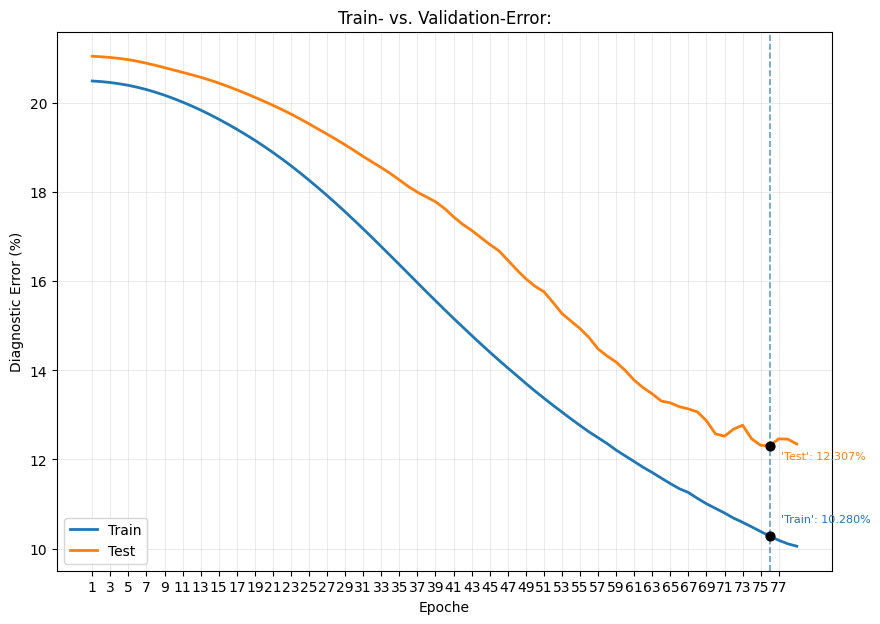

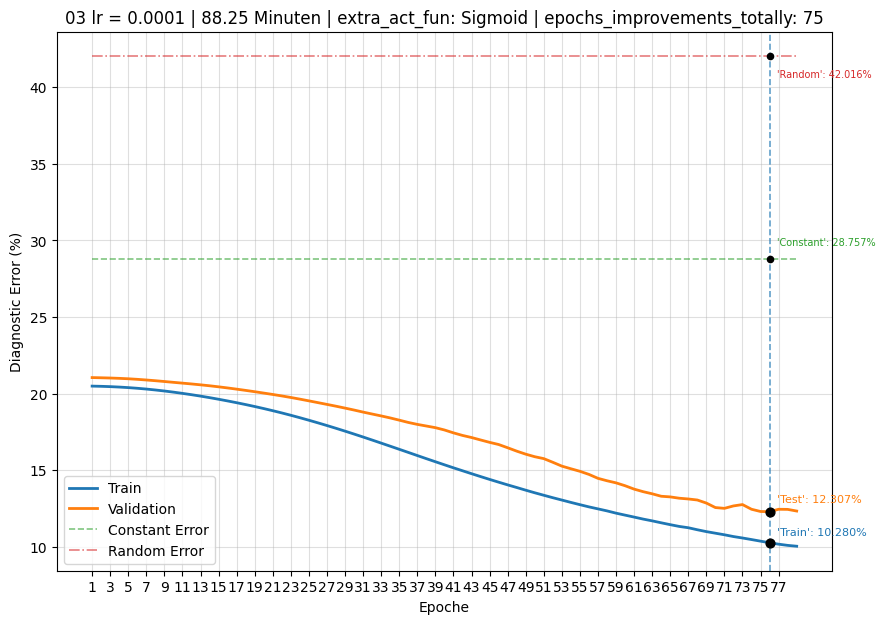

In [53]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Validation-Error: {np.float64(diag_val_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Validation-Error-Max: {np.max(diag_val_error)}\t Diagonal-Validation-Error-Min: {np.min(diag_val_error)}\t max_needed_epochs: {e+2}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")

# Session: 01
# if globals().get("bas_const_err") is None:
#     bas_const_err = 28.776

# if globals().get("bas_rand_err") is None:
#     bas_rand_err = 39.232


# Session: 03
if globals().get("bas_const_err") is None:
    bas_const_err = 28.7569

if globals().get("bas_rand_err") is None:
    bas_rand_err  = 42.0157 
    

# Curven:

# Minimum Test Error bestimmen
min_val_error = min(diag_val_error)
min_val_epoch = diag_val_error.index(min_val_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_val_epoch - 1]
val_at_min = diag_val_error[min_val_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
val_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_val_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Validation Error
plt.plot(epochs, diag_val_error, label="Test", linewidth=2, color=val_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=val_color,
    fontsize=8,
)


plt.title("Train- vs. Validation-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(np.arange(min(epochs), max(epochs), 2))

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Validation Error
plt.plot(
    epochs,
    diag_val_error,
    label="Validation",
    linewidth=2,
    color=val_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_val_epoch}")
print(f"Validation Error:      {val_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_val_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=val_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_val_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_val_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{session} "
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"epochs_improvements_totally: {e + 2}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(np.arange(min(epochs), max(epochs), 2))

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs('./rusults/personal/Newcompare_diagrams/', exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"./rusults/personal/Newcompare_diagrams//diag_error_{session}_{learning_rate}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# a_random:
session: 03

 Diagonal-Train-Error: 
 [20.497  20.4834 20.4632 20.4347 20.3996 20.356  20.3048 20.2449 20.1784
 20.1043 20.0235 19.9373 19.8448 19.7457 19.6404 19.5298 19.4139 19.2931
 19.1662 19.0325 18.893  18.7473 18.5949 18.4359 18.2707 18.1002 17.9252
 17.7448 17.5597 17.3697 17.1764 16.9794 16.7795 16.5783 16.3759 16.1726
 15.9681 15.765  15.5648 15.3652 15.1685 14.9767 14.7855 14.5972 14.4123
 14.232  14.055  13.8841 13.709  13.5395 13.378  13.2181 13.0656 12.9119
 12.7638 12.6197 12.4891 12.3578 12.2104 12.0816 11.9542 11.8238 11.7078
 11.5814 11.4595 11.344  11.2589 11.1274 11.006  10.9026 10.7993 10.6839
 10.5902 10.4884 10.3829 10.2804 10.1862 10.1084 10.0531]

 Diagonal-Validation-Error: 
 [21.0535 21.0406 21.0251 21.0034 20.9759 20.9397 20.8965 20.8487 20.7971
 20.7436 20.6912 20.6382 20.5809 20.5193 20.4509 20.3773 20.2991 20.2173
 20.1321 20.0426 19.952  19.8566 19.7556 19.6477 19.5349 19.4194 19.3038
 19.1863 19.0629 18.9359 18.8021 18.6763 18.5522 18.4213 18.2769 18.1273
 18.0007 17.8943 17.7865 17.6364 17.4478 17.2808 17.1446 16.9855 16.8292
 16.6885 16.4765 16.2567 16.0588 15.8918 15.7671 15.5286 15.2783 15.1069
 14.9404 14.7381 14.4815 14.3236 14.1863 13.9997 13.7788 13.6115 13.4729
 13.3127 13.2708 13.1848 13.1353 13.0678 12.8684 12.575  12.5239 12.6816
 12.7703 12.4643 12.3188 12.3068 12.4634 12.4566 12.3478]


 Diagonal-Train-Error-Max: 20.497 	        Diagonal-Train-Error-Min: 10.0531	
 Diagonal-Validation-Error-Max: 21.0535	    Diagonal-Validation-Error-Min: 12.3068	           max_needed_epochs: 75
 
 totll running-tiems (min): 88.25 Minuten


Minimum Test Error:
Epoch:                 76
Validation Error:      12.3068%
Train Error:           10.2804%
Constant Error:        28.7569%
Random Error:          42.0157%

# Test:
* Session: 03
* MAE : 0.0734
* RMSE: 0.0949
* Diagonal-Error : 6.7092 %
* test_diag_error = 6.7092%


# Test:
* Session: 03
* MAE : 0.1503
* RMSE: 0.1824 
* test_diag_error = 12.8958 %

# ================================================================================================

b1) sequential:
session: 03 

 Diagonal-Train-Error: [20.4734 20.434  20.3619 20.2566 20.1315 20.0039 19.8758 19.7453 19.6044
 19.4389 19.2593 19.0579 18.8418 18.5957 18.327  18.024  17.68   17.3228
 16.9188 16.5125 16.0577 15.6182 15.1587 14.6237 14.0987 13.6284 13.1482
 12.6038 12.0918 11.5639 11.0552 10.5529 10.0504  9.5557  9.0125  8.525
  8.0616  7.6321  7.2532  6.8485  6.4839  6.1019  5.815   5.5005  5.2699
  4.9691  4.7712  4.5204  4.3534  4.157   4.009   3.8775  3.7054  3.5916
  3.4916  3.4304  3.2971  3.1581  3.0936  3.035   2.9875]

 Diagonal-Validation-Error: [21.0789 21.0385 20.9773 20.9093 20.8291 20.7547 20.675  20.5876 20.4794
 20.3646 20.2192 20.071  19.9093 19.7336 19.5208 19.2781 19.0017 18.7326
 18.3673 17.9969 17.5618 17.1835 16.7869 16.2901 15.8112 15.2803 14.7942
 14.2626 13.7438 13.2294 12.8184 12.3282 11.7988 11.3553 10.9598 10.4758
 10.0988  9.6982  9.3955  9.1695  8.9442  8.6453  8.4306  8.323   8.3117
  8.2503  8.0054  7.8579  7.8058  7.6049  7.5505  7.4823  7.4169  7.3668
  7.3405  7.3579  7.3611  7.1191  7.1942  7.1688  7.128 ]


 Diagonal-Train-Error-Max: 20.4734 	       Diagonal-Train-Error-Min: 2.9875	
 Diagonal-Validation-Error-Max: 21.0789	   Diagonal-Validation-Error-Min: 7.1191	 max_needed_epochs: 57



Minimum Error:
Epoch:                 58
Validation Error:      7.1191%
Train Error:           3.1581%
Constant Error:        28.7569%
Random Error:          40.4452%


# ===============================================================================================
d: two Videos
session: 03

 Diagonal-Train-Error: [20.4943 20.4205 20.3222 20.2067 20.099  19.9595 19.8481 19.695  19.555
 19.3986 19.2236 19.0826 18.847  18.6135 18.3637 18.1207 17.842  17.5889
 17.3044 17.0534 16.6926 16.365  15.9398 15.6131 15.416  14.6871 14.3851
 13.9832 13.6334 13.3919 13.1806 12.6639 12.0695 11.8195 11.4011 10.9265
 10.6008 10.2857 10.2497  9.7905  9.4225  9.3187  9.0837  8.8702  8.4353
  8.2733  7.9494  7.6057  7.4646  7.1788  6.9277  6.9685  6.968   6.8493]

 Diagonal-Test-Error: [19.9141 19.8758 19.7909 19.7179 19.6388 19.5554 19.4617 19.3517 19.247
 19.104  18.9699 18.8496 18.679  18.495  18.305  18.0962 17.8542 17.6387
 17.4103 17.1899 16.8777 16.6347 16.24   15.9645 15.7293 15.2073 14.9025
 14.5639 14.3895 14.1429 13.9575 13.5442 13.1274 12.7653 12.4627 12.1037
 11.7685 11.5732 11.6008 11.1178 10.8408 10.773  10.6023 10.2894 10.0266
 10.0704  9.8214  9.4245  9.3022  9.2181  9.0643  9.1174  9.0819  9.0703]


 Diagonal-Train-Error-Max: 20.4943 	 Diagonal-Train-Error-Min: 6.8493	
 Diagonal-Test-Error-Max: 19.9141	 Diagonal-Test-Error-Min: 9.0643	 max_needed_epochs: 50



Minimum Test Error:
Epoch:           51
Validation Error:      9.0643%
Train Error:     6.9277%
Constant Error:  28.7569%
Random Error:    40.4452%

# ---------- Evaluation ----------

In [55]:
# ---------- Evaluation ----------

# saved_model = "./models/best_models/best_ResNet_Sigmoid.path"

best_saved_model2 = "./models/personal/BEST_MODELS_session(03).path"

saved_model_name = "models/personal/ResNet_best_model_lr(1e-05)_session(10).path"

last_saved_model = "models/personal/BEST-MODEL_RESNET_SIGMOID_session(03).path"

last_saved_model2 = "models/personal/BEST-MODEL_RESNET_SIGMOID_session(03+04).path"

# saved_model = "./models/best_models/best_ResNet_Sigmoid.path"

checkpoint = torch.load(
    # saved_model_name,
    best_saved_model2,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()

print("Test:\n")
print(f"Session: {session}")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error = {test_diag_pct:.4f}% "
    )

targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test:

Session: 03
MAE : 0.1503 	 RMSE: 0.1824 
Diagonal-Error %: 12.8958 %
test_diag_error = 12.8958% 


# Test: two Videos 03 + 04

session: 04

MAE : 0.2541 --|-- RMSE: 0.2971 

Diagonal-Error %: 21.0104 %

test_diag_error = 21.0104% 

# Test:

Session: 03

MAE : 0.0734 --|-- RMSE: 0.0949 

Diagonal-Error : 6.7092 %

test_diag_error = 6.7092% 

# Test:

MAE : 0.1341 	 RMSE: 0.1672 

Diagonal-Error %: 11.8241 %

test_diag_error=11.8241%

In [33]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    f"results/personal/predictions_{session}.csv",
    index=False
)

# Split:

    a) random: 70% train, 15% validation, 15% test
    b) sequential: first 70% train, next 15% validation, last 15% test

    c) first Video for train and validation, another Video for test

    d1) train and validation: after every 5 Second start movement with a random Startpoint
    d2) test: frames start 0.5 sec after every new Starting

    e) another Video with another camera und lighing-conditions


In [50]:
dirs = f"personalization/{session}"

csv_path = Path(dirs) / "norm_labels.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fehlt: {csv_path.resolve()}")

df = pd.read_csv(csv_path)

dataset_size = len(df)

print(f"Gesamte Daten: {dataset_size}")


# ============================================================
# Vollständiges Dataset
# ============================================================

full_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
)

print(f"len(full_dataset): {len(full_dataset)}")


Gesamte Daten: 498


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 498/498 [00:05<00:00, 93.69it/s]

len(full_dataset): 498


In [58]:
train_size = int(dataset_size * 0.70)
validat_size = int(dataset_size * 0.15)

test_size = dataset_size - train_size - validat_size

print(
    f"\nTrain:      {train_size} | "
    f"Validation: {validat_size} | "
    f"Test:       {test_size} | "
    f"\n\nSumme:      {train_size + validat_size + test_size}"
)



Train:      348 | Validation: 74 | Test:       76 | 

Summe:      498


# Func: Create Splits

In [75]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5,
    test_dataset=None
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

# a) random 

In [67]:

from torch.utils.data import DataLoader, Subset, random_split


# A1: Random
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42
)


print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



# B1: Sequential:

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")



# B2: another Split but better: first Test next Train and Validation

all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")




# C: C: one Video for Train and Validation and another Video for Test
session1, session2 = str('03'), str('04') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")
print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")
print(f"Session2 Test: {session2}-->{len(test_dataset)}")


train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)



# d: every 5 sec but after 0.5 sec:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)






Train:      348
Validation: 74
Test:       76


# b: Sequential:

In [ ]:
# B1:

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


In [ ]:
# B2: another Split but better: first Test next Train and Validation



all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      348
Validation: 74
Test:       76


# C: one Video for Train and Validation and another Video for Test


In [76]:
session1, session2 = str('03'), str('04') 

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size

print(f"Session1: {session1}-->{dataset_size}")

print(f"Train:      {train_size}")
print(f"Validation: {validat_size}")

print(f"Session2 Test: {session2}-->{len(test_dataset)}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 548/548 [00:05<00:00, 108.46it/s]


Session1: 03-->482
Train:      385
Validation: 97
Session2 Test: 04-->548


In [77]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_dataset
)



DIFFERENT-VIDEO SPLIT
Train/Validation Video: 482 Samples
Test Video: 548 Samples

Split:
Train:       385
Validation:  97
Test:        548


# d: every 5 sec first after 0.5 sec:

In [ ]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)


# Test 

In [ ]:
def verify_dataset(
    dataset,
    csv_file,
    num_samples=20
):

    df = pd.read_csv(csv_file)

    print("=" * 60)
    print("DATASET VERIFICATION")
    print("=" * 60)

    print(f"CSV rows:      {len(df)}")
    print(f"Dataset size:  {len(dataset)}")

    assert len(df) == len(dataset), (
        "CSV und Dataset haben unterschiedliche Größen!"
    )

    num_samples = min(
        num_samples,
        len(dataset)
    )

    for idx in np.linspace(
        0,
        len(dataset) - 1,
        num_samples,
        dtype=int
    ):

        image, target = dataset[idx]

        csv_row = df.iloc[idx]

        csv_target = np.array(
            [
                csv_row["x"],
                csv_row["y"]
            ],
            dtype=np.float32
        )

        dataset_target = target.numpy()

        if not np.allclose(
            csv_target,
            dataset_target,
            atol=1e-6
        ):

            print(
                f"FEHLER bei Index {idx}"
            )

            print(
                "CSV:",
                csv_target
            )

            print(
                "Dataset:",
                dataset_target
            )

            return False

    print(
        f"\n✓ {num_samples} Samples erfolgreich überprüft."
    )

    return True


In [ ]:
verify_dataset(
    full_dataset,
    Path(dirs) / "norm_labels.csv",
    num_samples=20
)

In [ ]:
train_indices = set(train_dataset.indices)
validat_indices = set(validat_dataset.indices)
test_indices = set(test_dataset.indices)

print(
    "Train ∩ Validation:",
    len(train_indices & validat_indices)
)

print(
    "Train ∩ Test:",
    len(train_indices & test_indices)
)

print(
    "Validation ∩ Test:",
    len(validat_indices & test_indices)
)

# Results:
# Train ∩ Validation = 0
# Train ∩ Test       = 0
# Validation ∩ Test  = 0

In [ ]:
all_used = (
    train_indices
    | validat_indices
    | test_indices
)

print(
    "Anzahl verwendeter Samples:",
    len(all_used)
)

# Results: Bei deinem Reset-aware Split darf len(all_used) sogar kleiner als len(full_dataset) sein


In [19]:
# 01:
print(f"the results for Session: {session}")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01


Diagonal_train_error: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden
totll running-tiems (min): 5.19 Minuten



# the results for Session: 01
## only FC and without layer 4

Diagonal_train_error01: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error01: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden

totll running-tiems (min): 5.19 Minuten

In [24]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden
totll running-tiems (min): 4.88 Minuten



# the results for Session: 02

## only FC and without layer 4


Diagonal_train_error02: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error02: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden

totll running-tiems (min): 4.88 Minuten

In [29]:
# 03:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 03

only FC and without layer 4



Diagonal_train_error: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden
totll running-tiems (min): 5.62 Minuten



## the results for Session: 03

# only FC and without layer 4


Diagonal_train_error03: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error03: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden

totll running-tiems (min): 5.62 Minuten


In [51]:
# 04:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 04

only FC and without layer 4



Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden
totll running-tiems (min): 5.57 Minuten



# the results for Session: 04

## only FC and without layer 4


Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden

totll running-tiems (min): 5.57 Minuten


# ==================== Optimal =============================

In [56]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [19.4212 17.7688 16.9373 16.432  15.9572 15.5047 15.0849 14.7342 14.4432
 14.2265 14.0141 13.781  13.5563 13.348  13.1246 12.9289 12.7407 12.5674
 12.3858 12.2026]


Diagonal_test_error: [20.9319 17.7764 15.8419 14.8768 14.4095 14.1325 14.111  14.2164 14.2938
 14.2955 14.1694 13.848  13.4551 13.3329 13.005  12.886  12.8297 12.8031
 12.6214 12.4136]

 epochs: 20, 	 best_Error: 0.17555457971299732
 best_test_error: 12.4136%, 	max_test_Error: 20.9319%

totll running-tiems (s): 574.36 Sekunden
totll running-tiems (min): 9.57 Minuten



In [62]:
# 01:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

only FC and without layer 4



Diagonal_train_error: [15.3648 15.1013 15.1603 14.678  14.3885 14.2098 14.0774 13.9202 13.78
 13.657  13.5354 13.4318 13.3666 13.243  13.1577 13.0428 12.9579 12.9177
 12.7877 12.7263]


Diagonal_test_error: [16.7358 16.2906 16.3221 15.8886 15.7614 15.5712 15.2743 15.2488 15.1827
 15.0881 14.9273 14.8744 14.7402 14.6438 14.6689 14.6622 14.6104 14.5191
 14.4285 14.46  ]

 epochs: 20, 	 best_Error: 0.2040497107098068
 best_test_error: 14.4285%, 	max_test_Error: 16.7358%

totll running-tiems (s): 788.43 Sekunden
totll running-tiems (min): 13.14 Minuten



In [65]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 



Diagonal_train_error: [11.3647 10.2059  9.183   8.3242  7.5884  7.1476  6.4918  5.9299  5.6028
  5.1456  4.8113  4.533   4.2175  4.0028  3.7746  3.6418  3.4019  3.2304
  3.0697  3.1854]


Diagonal_test_error: [13.5827 12.993  12.4911 12.0546 11.8701 11.8472 11.48   10.8924 10.5413
 10.593  10.3502 10.3507 10.138  10.1412 10.1741 10.1195 10.0583  9.904
  9.8323  9.8302]

 epochs: 20, 	 best_Error: 0.1390205620095576
 best_test_error: 9.8302%, 	max_test_Error: 13.5827%

totll running-tiems (s): 1350.90 Sekunden
totll running-tiems (min): 22.51 Minuten



In [12]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 and Sigmoid \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 and Sigmoid 



Diagonal_train_error: [21.2963 20.4879 19.7773 19.1741 18.6438 18.159  17.7288 17.3245 16.9491
 16.5914 16.2423 15.8723 15.5279 15.1753 14.8057 14.446  14.0653 13.6825
 13.2886 12.9093]


Diagonal_test_error: [22.5788 21.8181 21.181  20.6503 20.1906 19.7427 19.3522 18.9706 18.6466
 18.3322 18.0399 17.7275 17.4513 17.1487 16.8487 16.573  16.2839 16.0158
 15.7229 15.4488]

 epochs: 20, 	 best_Error: 0.2184786646452124
 best_test_error: 15.4488%, 	max_test_Error: 22.5788%

totll running-tiems (s): 1438.26 Sekunden
totll running-tiems (min): 23.97 Minuten

